**Crop Recommendation System Using Machine Learning**

In [1]:
# Data processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

Load Dataset

In [2]:
df = pd.read_csv("Crop_recommendation.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


Checking dataset shape

In [3]:
df.shape

(2200, 8)

Checking column names

In [4]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

Dataset Overview

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


Check missing values

In [6]:
df.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


Checking crop classes

In [7]:
df['label'].value_counts()

,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


Crop distribution

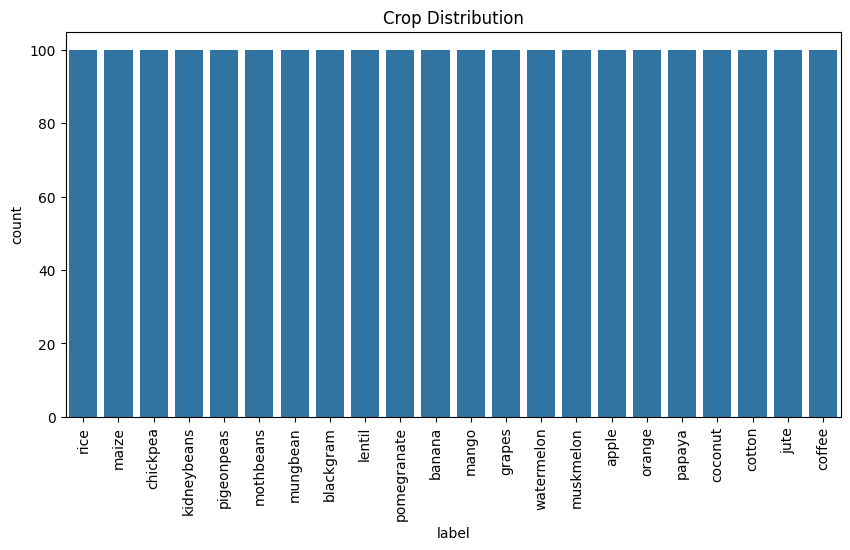

In [8]:
plt.figure(figsize=(10,5))
sns.countplot(x='label', data=df)
plt.xticks(rotation=90)
plt.title("Crop Distribution")
plt.show()

Feature and Target

In [9]:
X = df.drop('label', axis=1)
y = df['label']

Train/Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Feature Scaling

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Train Multiple Models

In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    results[name] = acc

results

{'Logistic Regression': 0.9636363636363636,
 'Decision Tree': 0.9840909090909091,
 'Random Forest': 0.9931818181818182,
 'KNN': 0.9568181818181818,
 'SVM': 0.9681818181818181}

Find Best Model

In [13]:
best_model = max(results, key=results.get)
print("Best Model:", best_model)

Best Model: Random Forest


Train Final Model

In [14]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

Crop Prediction Function

In [15]:
def predict_crop(N, P, K, temp, humidity, ph, rainfall):

    data = np.array([[N, P, K, temp, humidity, ph, rainfall]])

    data = scaler.transform(data)

    prediction = model.predict(data)

    return prediction[0]

Test it

In [16]:
predict_crop(90, 42, 43, 20.5, 80, 6.5, 200)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


'rice'

Convert into an APP

In [17]:
!pip install gradio

Build the App

In [18]:
import gradio as gr

def crop_app(N, P, K, temperature, humidity, ph, rainfall):

    data = np.array([[N,P,K,temperature,humidity,ph,rainfall]])
    data = scaler.transform(data)

    prediction = model.predict(data)

    return prediction[0]

interface = gr.Interface(

    fn=crop_app,

    inputs=[
        gr.Number(label="Nitrogen"),
        gr.Number(label="Phosphorus"),
        gr.Number(label="Potassium"),
        gr.Number(label="Temperature"),
        gr.Number(label="Humidity"),
        gr.Number(label="pH"),
        gr.Number(label="Rainfall")
    ],

    outputs="text",

    title="Crop Recommendation System",

    description="Enter soil and weather parameters to predict the best crop."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://db3a8f4a0964a190bb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
